<a href="https://colab.research.google.com/github/Jeffrey-AI-research/Stock-Market-Predictions-AI-Research/blob/main/Stock_Market_Predictions_AI_Research_(Revision_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")

In [4]:
# Data Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6290 non-null   object 
 1   Open       6290 non-null   float64
 2   High       6290 non-null   float64
 3   Low        6290 non-null   float64
 4   Close      6290 non-null   float64
 5   Adj Close  6290 non-null   float64
 6   Volume     6290 non-null   int64  
 7   Ticker     6290 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 393.3+ KB


In [5]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Ticker,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6290 non-null   datetime64[ns]
 1   Open       6290 non-null   float64       
 2   High       6290 non-null   float64       
 3   Low        6290 non-null   float64       
 4   Close      6290 non-null   float64       
 5   Adj Close  6290 non-null   float64       
 6   Volume     6290 non-null   int64         
 7   Ticker     6290 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 393.3+ KB


In [8]:
# exploratory data analysis
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,6290,6290.000000,6290.000000,6290.000000,6290.000000,6290.000000,6.290000e+03
mean,2021-06-30 18:48:38.918919168,151.162151,153.244131,149.026081,151.204223,149.758827,7.490120e+07
min,2019-01-02 00:00:00,12.073333,12.445333,11.799333,11.931333,11.931333,8.989200e+06
25%,2020-04-01 00:00:00,93.082499,94.356625,91.825003,93.113749,92.949377,3.114190e+07
50%,2021-06-30 12:00:00,137.934746,139.455002,136.264999,137.790001,136.450951,5.853630e+07
75%,2022-09-29 00:00:00,193.560001,196.315006,190.919998,193.577503,192.476280,9.604528e+07
max,2023-12-29 00:00:00,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08
std,NaN,80.989939,82.186810,79.665983,80.943887,80.144988,6.252449e+07


In [9]:
df["Ticker"].value_counts()

,count
Ticker,
AAPL,1258
MSFT,1258
AMZN,1258
GOOGL,1258
TSLA,1258


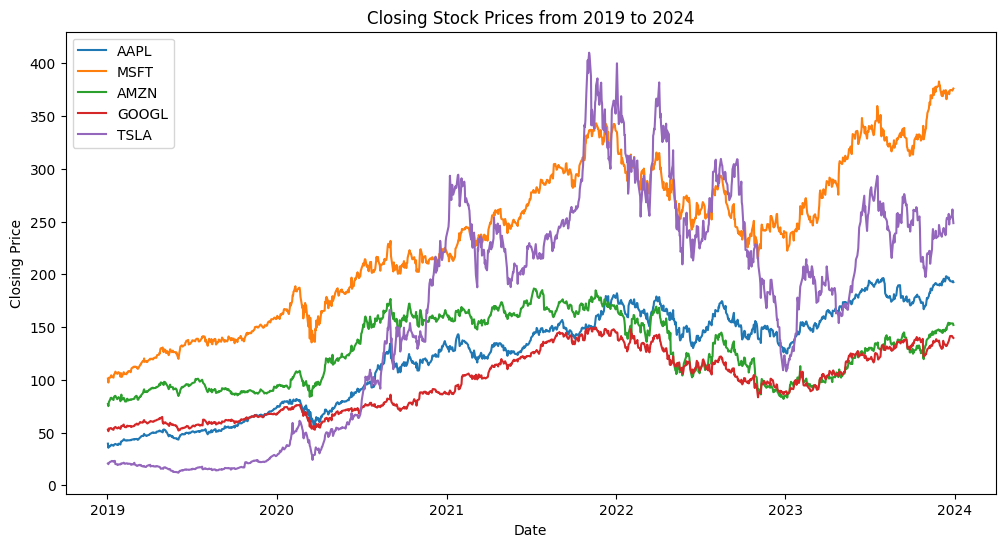

In [10]:
# exploratory data analysis - Closing Stock prices
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6)) # Make new graph(12in x 6in)
for ticker in df["Ticker"].unique(): # For each ticker, filter data table
    stock = df[df["Ticker"] == ticker]
    plt.plot(stock["Date"], stock["Close"], label=ticker)

plt.title("Closing Stock Prices from 2019 to 2024")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend() # Creates the reference(top left)

plt.savefig("closing_prices.png", dpi=300, bbox_inches="tight") # Saves visualization/graph
plt.show()

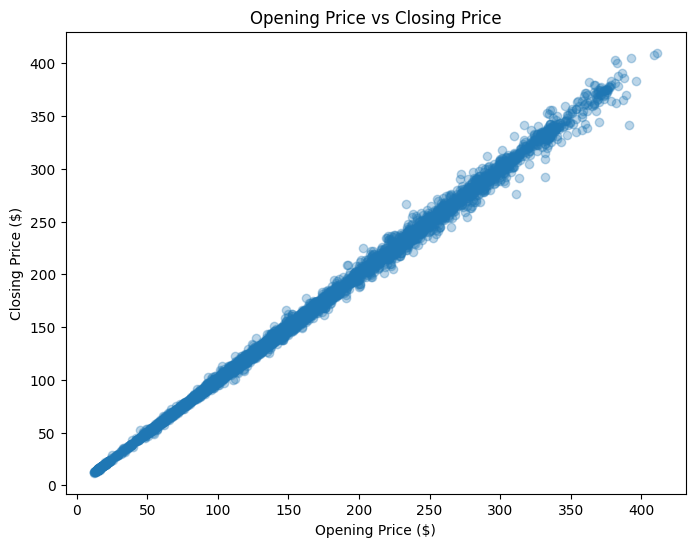

In [11]:
# exploratory data analysis - Open Price vs Closing Price
plt.figure(figsize=(8,6)) # Make new graph(8in x 6in)
plt.scatter(df["Open"], df["Close"], alpha=0.3) # alpha: transparency

plt.title("Opening Price vs Closing Price")
plt.xlabel("Opening Price ($)")
plt.ylabel("Closing Price ($)")

plt.savefig("open_vs_close.png", dpi=300, bbox_inches="tight") # Saves visualization/graph
plt.show()


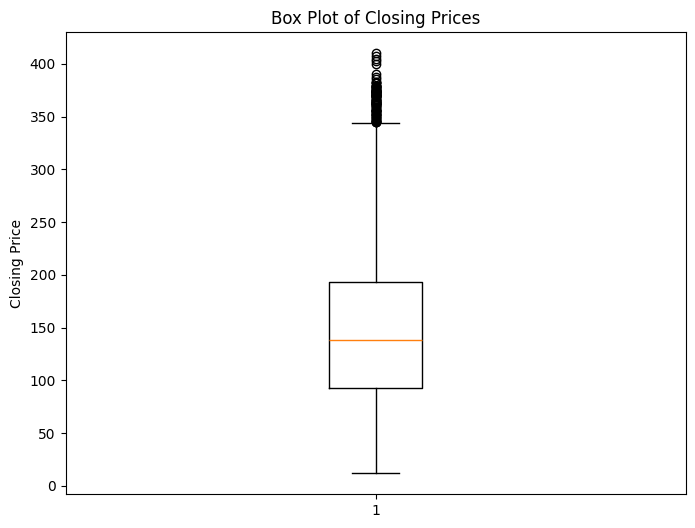

In [12]:
# exploratory data analysis - Potential Issues for Closing Prices
plt.figure(figsize=(8,6)) # Make new graph(8in x 6in)
plt.boxplot(df["Close"])

plt.title("Box Plot of Closing Prices")
plt.ylabel("Closing Price")

plt.savefig("closing_price_boxplot.png", dpi=300, bbox_inches="tight") # Saves visualization/graph
plt.show()
# The points above the range are "outliers" and are each explicitly shown; other points are "normal" and not explicitly shown.

In [13]:
# Training Machine Learning Model (Linear Regression)

In [14]:
df["Target"] = df.groupby("Ticker")["Close"].shift(-1) # Create the target variable

df = df.dropna() # Remove rows with missing target values

In [22]:
df = df.sort_values("Date") # Sort the data by date

In [24]:
X = df[["Open", "High", "Low", "Volume"]]
y = df["Target"]

In [23]:
split_index = int(len(df) * 0.8) # Split data to "train(2019-2023)" and "test(2024)"

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # Create and train the model
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test) # Predict stock prices

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9967406471402193
Mean Absolute Error: 3.0047394426506346
Root Mean Squared Error: 4.461834528552905


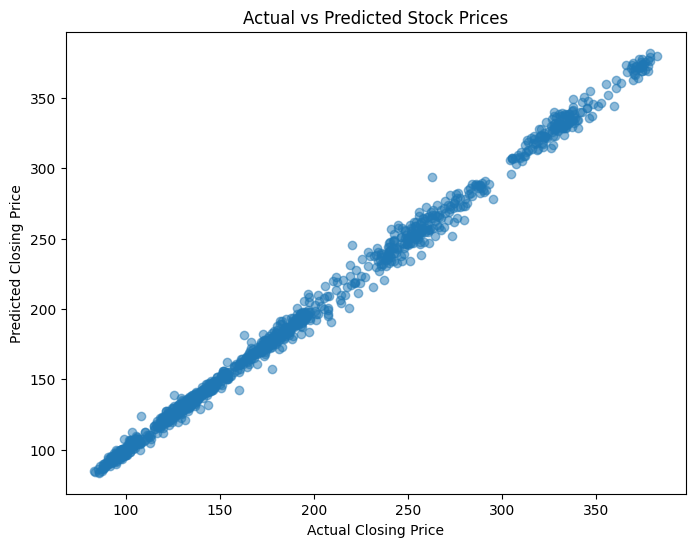

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Stock Prices")

plt.savefig("scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()